In [1]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.cleaning import (
    missing_values_table,
    plot_boxplots_grid,
    reorder_cols,
    spaces_to_snake,
    uniques_by_col,
)

pd.set_option("display.max_columns", None)

In [2]:
PROJECT_ROOT = Path("../..")
RAW_DATA_PATH = PROJECT_ROOT / "data/raw/housing/AmesHousing.csv"
DTYPES_PATH = PROJECT_ROOT / "references/DTYPES_AmesHousingDataset.json"

CLEANED_DATA_PATH = PROJECT_ROOT / "data/cleaned"

# Loading Data

First, let's load the file and have an overview of the data in order to best decide our next steps to clean the dataset

In [3]:
with DTYPES_PATH.open("r") as file:
    dtypes = json.load(file)

df = pd.read_csv(RAW_DATA_PATH, dtype=dtypes, true_values=["Y"], false_values=["N"])
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,0526301100,20,RL,141,31770,Pave,<NA>,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,TA,TA,CBlock,TA,Gd,Gd,BLQ,639,Unf,0,441,1080,GasA,Fa,True,SBrkr,1656,0,0,1656,1,0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960,Fin,2,528,TA,TA,P,210,62,0,0,0,0,<NA>,<NA>,<NA>,0,5,2010,WD,Normal,215000
1,2,0526350040,20,RH,80,11622,Pave,<NA>,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,<NA>,0,TA,TA,CBlock,TA,TA,No,Rec,468,LwQ,144,270,882,GasA,TA,True,SBrkr,896,0,0,896,0,0,1,0,2,1,TA,5,Typ,0,<NA>,Attchd,1961,Unf,1,730,TA,TA,Y,140,0,0,0,120,0,<NA>,MnPrv,<NA>,0,6,2010,WD,Normal,105000
2,3,0526351010,20,RL,81,14267,Pave,<NA>,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,TA,TA,CBlock,TA,TA,No,ALQ,923,Unf,0,406,1329,GasA,TA,True,SBrkr,1329,0,0,1329,0,0,1,1,3,1,Gd,6,Typ,0,<NA>,Attchd,1958,Unf,1,312,TA,TA,Y,393,36,0,0,0,0,<NA>,<NA>,Gar2,12500,6,2010,WD,Normal,172000
3,4,0526353030,20,RL,93,11160,Pave,<NA>,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,<NA>,0,Gd,TA,CBlock,TA,TA,No,ALQ,1065,Unf,0,1045,2110,GasA,Ex,True,SBrkr,2110,0,0,2110,1,0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968,Fin,2,522,TA,TA,Y,0,0,0,0,0,0,<NA>,<NA>,<NA>,0,4,2010,WD,Normal,244000
4,5,0527105010,60,RL,74,13830,Pave,<NA>,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,<NA>,0,TA,TA,PConc,Gd,TA,No,GLQ,791,Unf,0,137,928,GasA,Gd,True,SBrkr,928,701,0,1629,0,0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997,Fin,2,482,TA,TA,Y,212,34,0,0,0,0,<NA>,MnPrv,<NA>,0,3,2010,WD,Normal,189900


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   Int64  
 1   PID              2930 non-null   string 
 2   MS SubClass      2930 non-null   Int64  
 3   MS Zoning        2930 non-null   string 
 4   Lot Frontage     2440 non-null   Int64  
 5   Lot Area         2930 non-null   Int64  
 6   Street           2930 non-null   string 
 7   Alley            198 non-null    string 
 8   Lot Shape        2930 non-null   string 
 9   Land Contour     2930 non-null   string 
 10  Utilities        2930 non-null   string 
 11  Lot Config       2930 non-null   string 
 12  Land Slope       2930 non-null   string 
 13  Neighborhood     2930 non-null   string 
 14  Condition 1      2930 non-null   string 
 15  Condition 2      2930 non-null   string 
 16  Bldg Type        2930 non-null   string 
 17  House Style      2930 non

# Index, column names and dtypes

On the overview above we can extract some insights about the data:

* We can use PID as a index as it identifies uniquely each property
* Boolean fields are defined as 'Y' (Yes) and 'N' (No), we can convert this to actual boolean fields
* There are some columns with missing values: Misc Feature, Fence, Pool QC, Garage Cond, ...

Let's begin by setting the index, standardize the column names to snake_case, reorder the columns and setup the correct
dtypes. For the last action, we are going to use an additional file  [`references/DTYPES_AmesHousingDataset.json`](../../references/DTYPES_AmesHousingDataset.json) 
that contains all the correct dtypes.

In [5]:
df.columns = [spaces_to_snake(x) for x in df.columns]

df = df[reorder_cols(cols=list(df.columns), pk="pid", target="saleprice")]
df = df.drop(columns=["order"])
df = df.set_index("pid")

df.head()

,1st_flr_sf,2nd_flr_sf,3ssn_porch,alley,bedroom_abvgr,bldg_type,bsmt_cond,bsmt_exposure,bsmt_full_bath,bsmt_half_bath,bsmt_qual,bsmt_unf_sf,bsmtfin_sf_1,bsmtfin_sf_2,bsmtfin_type_1,bsmtfin_type_2,central_air,condition_1,condition_2,electrical,enclosed_porch,exter_cond,exter_qual,exterior_1st,exterior_2nd,fence,fireplace_qu,fireplaces,foundation,full_bath,functional,garage_area,garage_cars,garage_cond,garage_finish,garage_qual,garage_type,garage_yr_blt,gr_liv_area,half_bath,heating,heating_qc,house_style,kitchen_abvgr,kitchen_qual,land_contour,land_slope,lot_area,lot_config,lot_frontage,lot_shape,low_qual_fin_sf,mas_vnr_area,mas_vnr_type,misc_feature,misc_val,mo_sold,ms_subclass,ms_zoning,neighborhood,open_porch_sf,overall_cond,overall_qual,paved_drive,pool_area,pool_qc,roof_matl,roof_style,sale_condition,sale_type,screen_porch,street,total_bsmt_sf,totrms_abvgrd,utilities,wood_deck_sf,year_built,year_remod/add,yr_sold,saleprice
pid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0526301100,1656,0,0,<NA>,3,1Fam,Gd,Gd,1,0,TA,441,639,0,BLQ,Unf,True,Norm,Norm,SBrkr,0,TA,TA,BrkFace,Plywood,<NA>,Gd,2,CBlock,1,Typ,528,2,TA,Fin,TA,Attchd,1960,1656,0,GasA,Fa,1Story,1,TA,Lvl,Gtl,31770,Corner,141,IR1,0,112,Stone,<NA>,0,5,20,RL,NAmes,62,5,6,P,0,<NA>,CompShg,Hip,Normal,WD,0,Pave,1080,7,AllPub,210,1960,1960,2010,215000
0526350040,896,0,0,<NA>,2,1Fam,TA,No,0,0,TA,270,468,144,Rec,LwQ,True,Feedr,Norm,SBrkr,0,TA,TA,VinylSd,VinylSd,MnPrv,<NA>,0,CBlock,1,Typ,730,1,TA,Unf,TA,Attchd,1961,896,0,GasA,TA,1Story,1,TA,Lvl,Gtl,11622,Inside,80,Reg,0,0,<NA>,<NA>,0,6,20,RH,NAmes,0,6,5,Y,0,<NA>,CompShg,Gable,Normal,WD,120,Pave,882,5,AllPub,140,1961,1961,2010,105000
0526351010,1329,0,0,<NA>,3,1Fam,TA,No,0,0,TA,406,923,0,ALQ,Unf,True,Norm,Norm,SBrkr,0,TA,TA,Wd Sdng,Wd Sdng,<NA>,<NA>,0,CBlock,1,Typ,312,1,TA,Unf,TA,Attchd,1958,1329,1,GasA,TA,1Story,1,Gd,Lvl,Gtl,14267,Corner,81,IR1,0,108,BrkFace,Gar2,12500,6,20,RL,NAmes,36,6,6,Y,0,<NA>,CompShg,Hip,Normal,WD,0,Pave,1329,6,AllPub,393,1958,1958,2010,172000
0526353030,2110,0,0,<NA>,3,1Fam,TA,No,1,0,TA,1045,1065,0,ALQ,Unf,True,Norm,Norm,SBrkr,0,TA,Gd,BrkFace,BrkFace,<NA>,TA,2,CBlock,2,Typ,522,2,TA,Fin,TA,Attchd,1968,2110,1,GasA,Ex,1Story,1,Ex,Lvl,Gtl,11160,Corner,93,Reg,0,0,<NA>,<NA>,0,4,20,RL,NAmes,0,5,7,Y,0,<NA>,CompShg,Hip,Normal,WD,0,Pave,2110,8,AllPub,0,1968,1968,2010,244000
0527105010,928,701,0,<NA>,3,1Fam,TA,No,0,0,Gd,137,791,0,GLQ,Unf,True,Norm,Norm,SBrkr,0,TA,TA,VinylSd,VinylSd,MnPrv,TA,1,PConc,2,Typ,482,2,TA,Fin,TA,Attchd,1997,1629,1,GasA,Gd,2Story,1,TA,Lvl,Gtl,13830,Inside,74,IR1,0,0,<NA>,<NA>,0,3,60,RL,Gilbert,34,5,5,Y,0,<NA>,CompShg,Gable,Normal,WD,0,Pave,928,6,AllPub,212,1997,1998,2010,189900


# Duplicated columns

We don't have duplicated values in the dataset. So, there is nothing to do here in this step

In [6]:
df[df.duplicated(keep=False)].sort_index()

,1st_flr_sf,2nd_flr_sf,3ssn_porch,alley,bedroom_abvgr,bldg_type,bsmt_cond,bsmt_exposure,bsmt_full_bath,bsmt_half_bath,bsmt_qual,bsmt_unf_sf,bsmtfin_sf_1,bsmtfin_sf_2,bsmtfin_type_1,bsmtfin_type_2,central_air,condition_1,condition_2,electrical,enclosed_porch,exter_cond,exter_qual,exterior_1st,exterior_2nd,fence,fireplace_qu,fireplaces,foundation,full_bath,functional,garage_area,garage_cars,garage_cond,garage_finish,garage_qual,garage_type,garage_yr_blt,gr_liv_area,half_bath,heating,heating_qc,house_style,kitchen_abvgr,kitchen_qual,land_contour,land_slope,lot_area,lot_config,lot_frontage,lot_shape,low_qual_fin_sf,mas_vnr_area,mas_vnr_type,misc_feature,misc_val,mo_sold,ms_subclass,ms_zoning,neighborhood,open_porch_sf,overall_cond,overall_qual,paved_drive,pool_area,pool_qc,roof_matl,roof_style,sale_condition,sale_type,screen_porch,street,total_bsmt_sf,totrms_abvgrd,utilities,wood_deck_sf,year_built,year_remod/add,yr_sold,saleprice
pid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


# Missing Data

Now let's take a look on that missing data that we saw before.

In [7]:
missing_values_table(df)

,% missing,# total,# missing
pool_qc,99.556,2930,2917
misc_feature,96.382,2930,2824
alley,93.242,2930,2732
fence,80.478,2930,2358
mas_vnr_type,60.580,2930,1775
...,...,...,...
wood_deck_sf,0.000,2930,0
year_built,0.000,2930,0
year_remod/add,0.000,2930,0
yr_sold,0.000,2930,0


#### **CASE 01:** `pool_qc` (99%) and `misc_feature` (96%) - Not Missing at Random (NMAR)

The `pool_qc` variable indicates the quality of the pool and a missing value indicates the absence of one. Having 
a good quality pool sure can change the value of the house, however since we have only 13 observations split between 4 
quality categories, there isn't much data for the model to work with. 

Additionally, on the same dataset we have the `pool_area` variable that indicates the size of the pool. It is logical 
that a `pool_area == 0` is the same thing that having no pool. Since the absence of a pool is the 99% of the information
brought by `poll_qc`, this is, they are highly correlated, we can drop the variable without loosing a lot of information
for the model.

The same idea can be applied to `misc_feature` (related to `misc_val`).

In [8]:
df = df.drop(columns=["pool_qc", "misc_feature"], errors="ignore")

missing_values_table(df, filter_none=True)

,% missing,# total,# missing
alley,93.242,2930,2732
fence,80.478,2930,2358
mas_vnr_type,60.580,2930,1775
fireplace_qu,48.532,2930,1422
lot_frontage,16.724,2930,490
garage_finish,5.427,2930,159
garage_cond,5.427,2930,159
garage_yr_blt,5.427,2930,159
garage_qual,5.427,2930,159
garage_type,5.358,2930,157


#### **CASE 02:** `alley` (93%) and `fence` (80%) - Not Missing at Random (NMAR)

The case here is very similar CASE 01, however we don't have a high correlated variable that will provide almost the
same information. A good approach here is instead of having only a few itens with categories, is to binarize the 
information to indicate whether they have an alley or a fence (e.g. `has_alley` instead of using `alley`)

In [9]:
df["has_alley"] = df.apply(lambda row: not pd.isna(row["alley"]), axis=1)
df["has_fence"] = df.apply(lambda row: not pd.isna(row["fence"]), axis=1)

df = df.drop(columns=["alley", "fence"], errors="ignore")

missing_values_table(df, filter_none=True)

,% missing,# total,# missing
mas_vnr_type,60.580,2930,1775
fireplace_qu,48.532,2930,1422
lot_frontage,16.724,2930,490
garage_qual,5.427,2930,159
garage_cond,5.427,2930,159
garage_yr_blt,5.427,2930,159
garage_finish,5.427,2930,159
garage_type,5.358,2930,157
bsmt_exposure,2.833,2930,83
bsmtfin_type_2,2.765,2930,81


#### **CASE 03:** `mas_vnr_type` (60%) - Both Missing and Not missing at random

The `mas_vnr_type` variable indicates the type of masonry used in the construction. Here we have 40% of the data that
are filled, so binarizing or dropping will make us lose a lot of information. Since, not having masonry is also an
information we can fill the NAs with a category that indicates this.

However, if you look into `mas_vnr_area` that indicates the area of the masonry we see that it shares some nulls with
`mas_vnr_type` which can indicate that these values are MAR. For these cases we are going to drop them.

In [10]:
df[df["mas_vnr_type"].isna() & df["mas_vnr_area"].isna()]

,1st_flr_sf,2nd_flr_sf,3ssn_porch,bedroom_abvgr,bldg_type,bsmt_cond,bsmt_exposure,bsmt_full_bath,bsmt_half_bath,bsmt_qual,bsmt_unf_sf,bsmtfin_sf_1,bsmtfin_sf_2,bsmtfin_type_1,bsmtfin_type_2,central_air,condition_1,condition_2,electrical,enclosed_porch,exter_cond,exter_qual,exterior_1st,exterior_2nd,fireplace_qu,fireplaces,foundation,full_bath,functional,garage_area,garage_cars,garage_cond,garage_finish,garage_qual,garage_type,garage_yr_blt,gr_liv_area,half_bath,heating,heating_qc,house_style,kitchen_abvgr,kitchen_qual,land_contour,land_slope,lot_area,lot_config,lot_frontage,lot_shape,low_qual_fin_sf,mas_vnr_area,mas_vnr_type,misc_val,mo_sold,ms_subclass,ms_zoning,neighborhood,open_porch_sf,overall_cond,overall_qual,paved_drive,pool_area,roof_matl,roof_style,sale_condition,sale_type,screen_porch,street,total_bsmt_sf,totrms_abvgrd,utilities,wood_deck_sf,year_built,year_remod/add,yr_sold,saleprice,has_alley,has_fence
pid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0528240070,860,1100,0,4,1Fam,TA,No,1,0,Gd,235,625,0,GLQ,Unf,True,Norm,Norm,SBrkr,0,TA,Gd,VinylSd,VinylSd,TA,2,PConc,2,Typ,440,2,TA,Fin,TA,BuiltIn,2002,1960,1,GasA,Ex,2Story,1,Gd,Lvl,Gtl,7851,Inside,<NA>,Reg,0,<NA>,<NA>,0,5,60,RL,Gilbert,48,5,6,Y,0,CompShg,Gable,Normal,WD,0,Pave,860,8,AllPub,288,2002,2002,2010,216500,False,False
0528275160,878,1126,0,4,1Fam,TA,No,1,0,Ex,219,651,0,GLQ,Unf,True,Norm,Norm,SBrkr,0,TA,Gd,VinylSd,VinylSd,Gd,1,PConc,2,Typ,644,3,TA,Fin,TA,BuiltIn,2002,2004,1,GasA,Ex,2Story,1,Gd,Lvl,Gtl,12891,Corner,<NA>,IR1,0,<NA>,<NA>,0,7,60,RL,Gilbert,48,5,8,Y,0,CompShg,Gable,Normal,WD,0,Pave,870,8,AllPub,0,2002,2002,2009,257500,False,False
0528458020,1436,0,0,3,1Fam,TA,No,0,0,Ex,1436,0,0,Unf,Unf,True,Norm,Norm,SBrkr,0,TA,Gd,VinylSd,VinylSd,<NA>,0,PConc,2,Typ,529,2,TA,Fin,TA,Attchd,2008,1436,0,GasA,Ex,1Story,1,Gd,Lvl,Gtl,7993,Inside,90,IR1,0,<NA>,<NA>,0,10,20,FV,Somerst,121,5,7,Y,0,CompShg,Gable,Partial,New,0,Pave,1436,6,AllPub,0,2008,2009,2009,225000,False,False
0531371050,1200,0,0,2,1Fam,TA,No,1,0,Gd,343,833,0,GLQ,Unf,True,Norm,Norm,SBrkr,0,TA,Gd,VinylSd,VinylSd,<NA>,0,PConc,2,Typ,555,2,TA,RFn,TA,Attchd,2003,1200,0,GasA,Ex,1Story,1,Gd,Lvl,Gtl,10083,Inside,67,Reg,0,<NA>,<NA>,0,8,20,RL,SawyerW,41,5,7,Y,0,CompShg,Gable,Normal,WD,0,Pave,1176,5,AllPub,0,2003,2003,2009,184900,False,False
0907260030,840,885,0,3,1Fam,TA,No,0,0,Gd,840,0,0,Unf,Unf,True,Norm,Norm,SBrkr,0,TA,Gd,VinylSd,VinylSd,<NA>,0,PConc,2,Typ,550,2,TA,RFn,TA,Attchd,2002,1725,1,GasA,Ex,2Story,1,Gd,Lvl,Gtl,8749,Inside,70,Reg,0,<NA>,<NA>,0,11,60,RL,CollgCr,48,5,7,Y,0,CompShg,Gable,Normal,WD,0,Pave,840,6,AllPub,0,2002,2002,2009,198500,False,False
0528290090,707,707,0,3,1Fam,TA,No,0,0,Gd,707,0,0,Unf,Unf,True,RRAn,Norm,SBrkr,0,TA,Gd,VinylSd,VinylSd,Gd,1,PConc,2,Typ,403,2,TA,Fin,TA,Attchd,2002,1414,1,GasA,Ex,2Story,1,Gd,Lvl,Gtl,7750,Inside,<NA>,Reg,0,<NA>,<NA>,0,4,60,RL,Gilbert,35,5,7,Y,0,CompShg,Gable,Normal,WD,0,Pave,707,6,AllPub,100,2002,2002,2008,176000,False,False
0528439010,1460,0,0,3,1Fam,TA,No,0,0,Ex,794,666,0,GLQ,Unf,True,Feedr,Norm,SBrkr,0,TA,Gd,VinylSd,VinylSd,Gd,1,PConc,2,Typ,480,2,TA,Fin,TA,Attchd,2006,1460,0,GasA,Ex,1Story,1,Gd,Lvl,Gtl,10037,Corner,87,Reg,0,<NA>,<NA>,0,8,20,RL,Somerst,20,5,8,Y,0,CompShg,Hip,Normal,WD,0,Pave,1460,6,AllPub,0,2006,2007,2008,247000,False,False
0528462040,1428,0,0,3,1Fam,TA,No,0,0,Gd,1428,0,0,Unf,Unf,True,Norm,Norm,SBrkr,0,TA,Gd,CemntBd,CmentBd,<NA>,0,PConc,2,Typ,480,2,TA,Fin,TA,Attchd,2007,1428,0,GasA,Ex,1Story,1,Gd,Lvl,Gtl,11639,Corner,95,Reg,0,<NA>,<NA>,0,12,20,FV,Somerst,120,5,7,Y,0,CompShg,Gable,Partial,New,0,Pave,1428,6,AllPub,0,2007,2008,2008,182000,False,False
0528480160,822,843,0,3,1Fam,TA,No,0,0,Gd,813,0,0,Unf,Unf,True,Norm,Norm,SBrkr,0,TA,Gd,CemntBd,CmentBd,<NA>,0,PConc,2,Typ,562,2,TA,RFn,TA,Attchd,2007,1665,1,GasA,Ex,2Story,1,Gd,Lvl,Gtl,8125,Inside,65,Reg,0,<NA>,<NA>,0,5,60,FV,Somerst,0,6,7,Y,0,CompShg,Gable,Normal,WD,0,Pave,813,7,AllPub,0,2007,2007,2008,205950,False,False


In [11]:
df = df.dropna(subset=["mas_vnr_type", "mas_vnr_area"], how="all")

condition = df["mas_vnr_type"].isna() & (df["mas_vnr_area"] == 0)
df.loc[condition, "mas_vnr_type"] = "NoMasonry"

missing_values_table(df, filter_none=True)

,% missing,# total,# missing
fireplace_qu,48.607,2907,1413
lot_frontage,16.649,2907,484
garage_qual,5.435,2907,158
garage_finish,5.435,2907,158
garage_cond,5.435,2907,158
garage_yr_blt,5.435,2907,158
garage_type,5.366,2907,156
bsmt_exposure,2.855,2907,83
bsmtfin_type_2,2.786,2907,81
bsmt_cond,2.752,2907,80


#### **CASE 04:** `fireplace_qu` (49%) - Not Missing at Random

This case is similar with the mansonry (Case 03) if we relate `fireplaces_qu` (quality) and `fireplaces` (number of
fireplaces). However there are no cases of missing both variables. In this case we can just fill the NAs with a value
that indicates the absence of fireplaces.

In [12]:
df["fireplace_qu"] = df["fireplace_qu"].fillna("NoFireplace")

missing_values_table(df, filter_none=True)

,% missing,# total,# missing
lot_frontage,16.649,2907,484
garage_yr_blt,5.435,2907,158
garage_qual,5.435,2907,158
garage_finish,5.435,2907,158
garage_cond,5.435,2907,158
garage_type,5.366,2907,156
bsmt_exposure,2.855,2907,83
bsmtfin_type_2,2.786,2907,81
bsmt_qual,2.752,2907,80
bsmt_cond,2.752,2907,80


#### **CASE 05:** `lot_frontage` (16%) - Missing at Random

Every house needs to have an access, so it is required to have a `lot_frontage`. So, a missing value here indicates that
this values was probably not measured. Since 16% of the data is missing here we need to find a way to input data in
order to not lose all of this data. 

Looking at other varibles in the dataset, we can see that we have `lot_area`. It is reasonable to assume that these
values are high correlated. But let's check it using a scatter plot.

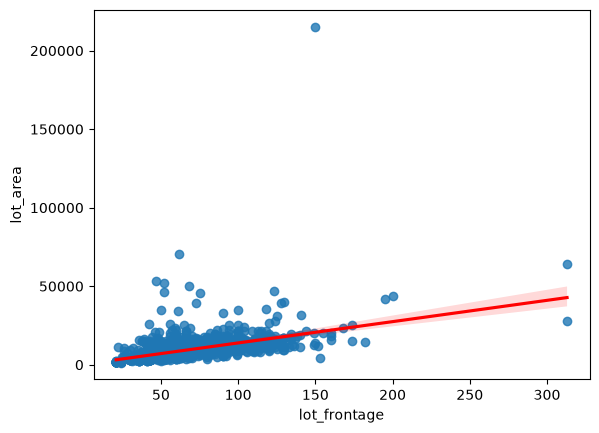

In [13]:
sns.regplot(x="lot_frontage", y="lot_area", data=df, line_kws={"color": "red"})
plt.show()

We can see from the plot above that there is a positive correlation between the area and the frontage (and that we have some outliers). So we are going to use this relationship to proportionally fill the missing values:

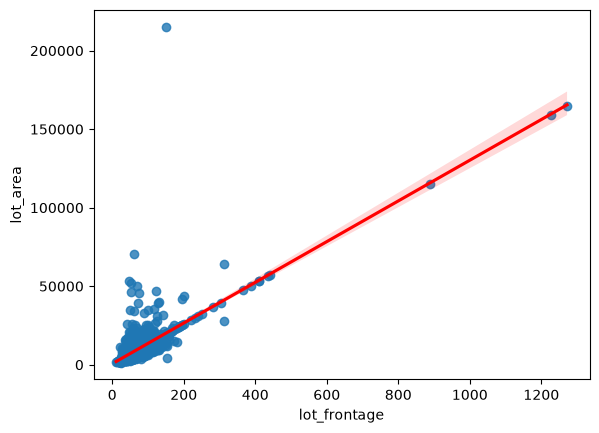

In [14]:
lot_frontage_area_ratio = (df.lot_frontage / df.lot_area).median()

missing = df["lot_frontage"].isna()

calculated_frontage = df.loc[missing, "lot_area"] * lot_frontage_area_ratio
df.loc[missing, "lot_frontage"] = calculated_frontage.astype("int64")

sns.regplot(x="lot_frontage", y="lot_area", data=df, line_kws={"color": "red"})
plt.show()

From the plot above, we can see that we changed the tendency of the values, however we proportionally assumed a lot frontage based on the area of the lot. And now we have no missing values

In [15]:
missing_values_table(df, filter_none=True)

,% missing,# total,# missing
garage_qual,5.435,2907,158
garage_yr_blt,5.435,2907,158
garage_cond,5.435,2907,158
garage_finish,5.435,2907,158
garage_type,5.366,2907,156
bsmt_exposure,2.855,2907,83
bsmtfin_type_2,2.786,2907,81
bsmtfin_type_1,2.752,2907,80
bsmt_qual,2.752,2907,80
bsmt_cond,2.752,2907,80


#### **CASE 06:** `garage_*` (5%)

For all the categorical variables related to garage, this is, `garage_qual`, `garage_cond`, `garage_finish`, 
`garage_type`. We are going to use the same approach as the case 3 (masonry) by relating this variables with
`garage_area` to create a new category indicating that there is no garage.

In [16]:
condition = df["garage_qual"].isna() & (df["garage_area"] == 0)
df.loc[condition, "garage_qual"] = "NoGarage"

condition = df["garage_cond"].isna() & (df["garage_area"] == 0)
df.loc[condition, "garage_cond"] = "NoGarage"

condition = df["garage_finish"].isna() & (df["garage_area"] == 0)
df.loc[condition, "garage_finish"] = "NoGarage"

condition = df["garage_type"].isna() & (df["garage_area"] == 0)
df.loc[condition, "garage_type"] = "NoGarage"


For the numerical one, this is, `garage_yr_blt` we need other approach. If we look
into the `year_built` variable we can see that most of garages (75%) were built in 
the same year of the house.

0.759889920880633

<Axes: xlabel='garage_yr_blt', ylabel='year_built'>

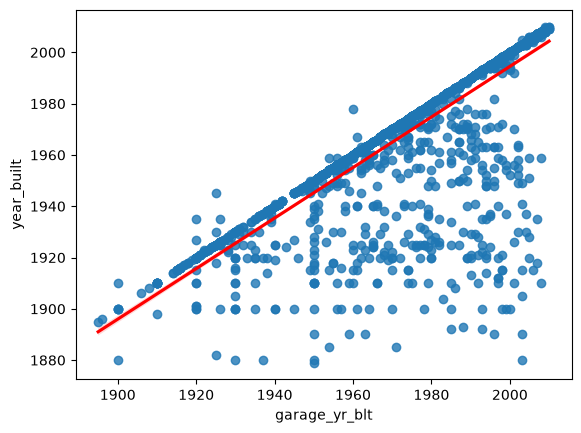

In [ ]:
print(len(df[df.garage_yr_blt == df.year_built]) / len(df))  # noqa: T201
sns.regplot(x="garage_yr_blt", y="year_built", data=df, line_kws={"color": "red"})

One possible approach here is to keep the same idea for the missing values and fill the
null values with the year built. However since they are missing because there is no
garage, using these values will create a contradiction. So, we are just going to drop
the column.

In [18]:
df = df.drop(columns=["garage_yr_blt"], errors="ignore")
missing_values_table(df, filter_none=True)

,% missing,# total,# missing
bsmt_exposure,2.855,2907,83
bsmtfin_type_2,2.786,2907,81
bsmt_cond,2.752,2907,80
bsmtfin_type_1,2.752,2907,80
bsmt_qual,2.752,2907,80
mas_vnr_type,0.241,2907,7
garage_cond,0.069,2907,2
garage_finish,0.069,2907,2
garage_qual,0.069,2907,2
bsmt_full_bath,0.069,2907,2


#### **CASE 07:** `bsmt_*` and `bsmtfin_*` and `total_bsmt_sf` (3%)

For the basement features, the logic is the same. The missing values actually indicates
the absence of basements. So we are going to use the same approach of the other similar
cases by relating the variables with `total_bsmt_sf`

In [19]:
condition = df["bsmt_exposure"].isna() & (df["total_bsmt_sf"] == 0)
df.loc[condition, "bsmt_exposure"] = "NoBasement"

condition = df["bsmtfin_type_1"].isna() & (df["total_bsmt_sf"] == 0)
df.loc[condition, "bsmtfin_type_1"] = "NoBasement"

condition = df["bsmtfin_type_2"].isna() & (df["total_bsmt_sf"] == 0)
df.loc[condition, "bsmtfin_type_2"] = "NoBasement"

condition = df["bsmt_cond"].isna() & (df["total_bsmt_sf"] == 0)
df.loc[condition, "bsmt_cond"] = "NoBasement"

condition = df["bsmt_qual"].isna() & (df["total_bsmt_sf"] == 0)
df.loc[condition, "bsmt_qual"] = "NoBasement"

In [20]:
missing_values_table(df, filter_none=True)

,% missing,# total,# missing
mas_vnr_type,0.241,2907,7
bsmt_exposure,0.138,2907,4
bsmt_full_bath,0.069,2907,2
bsmtfin_type_2,0.069,2907,2
bsmt_half_bath,0.069,2907,2
garage_qual,0.069,2907,2
garage_cond,0.069,2907,2
garage_finish,0.069,2907,2
bsmtfin_sf_2,0.034,2907,1
bsmtfin_sf_1,0.034,2907,1


#### Remaining Cases

Let's see the cases that could not be corrected

In [21]:
df.loc[df.isna().any(axis=1)]

,1st_flr_sf,2nd_flr_sf,3ssn_porch,bedroom_abvgr,bldg_type,bsmt_cond,bsmt_exposure,bsmt_full_bath,bsmt_half_bath,bsmt_qual,bsmt_unf_sf,bsmtfin_sf_1,bsmtfin_sf_2,bsmtfin_type_1,bsmtfin_type_2,central_air,condition_1,condition_2,electrical,enclosed_porch,exter_cond,exter_qual,exterior_1st,exterior_2nd,fireplace_qu,fireplaces,foundation,full_bath,functional,garage_area,garage_cars,garage_cond,garage_finish,garage_qual,garage_type,gr_liv_area,half_bath,heating,heating_qc,house_style,kitchen_abvgr,kitchen_qual,land_contour,land_slope,lot_area,lot_config,lot_frontage,lot_shape,low_qual_fin_sf,mas_vnr_area,mas_vnr_type,misc_val,mo_sold,ms_subclass,ms_zoning,neighborhood,open_porch_sf,overall_cond,overall_qual,paved_drive,pool_area,roof_matl,roof_style,sale_condition,sale_type,screen_porch,street,total_bsmt_sf,totrms_abvgrd,utilities,wood_deck_sf,year_built,year_remod/add,yr_sold,saleprice,has_alley,has_fence
pid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0528445060,1595,0,0,2,1Fam,TA,<NA>,0,0,Gd,1595,0,0,Unf,Unf,True,Norm,Norm,SBrkr,0,TA,Gd,VinylSd,VinylSd,Gd,1,PConc,2,Typ,880,3,TA,RFn,TA,Attchd,1595,0,GasA,Ex,1Story,1,Gd,Lvl,Gtl,8987,Inside,73,Reg,0,226,BrkFace,0,5,20,RL,Somerst,0,5,8,Y,0,CompShg,Gable,Normal,WD,0,Pave,1595,6,AllPub,144,2005,2006,2010,221500,False,False
0527166010,1005,978,0,3,1Fam,TA,No,0,0,Gd,284,694,0,GLQ,Unf,True,Norm,Norm,SBrkr,0,TA,Gd,VinylSd,VinylSd,TA,1,PConc,2,Typ,490,2,TA,Fin,TA,Attchd,1983,1,GasA,Ex,2Story,1,Gd,Lvl,Gtl,10762,CulDSac,83,IR1,0,344,<NA>,0,5,60,RL,Gilbert,0,5,7,Y,0,CompShg,Gable,Normal,WD,0,Pave,978,9,AllPub,0,1999,1999,2009,225000,False,False
0527451110,765,600,0,3,TwnhsE,TA,No,0,0,TA,0,765,0,LwQ,Unf,True,Norm,Norm,SBrkr,0,TA,TA,HdBoard,HdBoard,NoFireplace,0,CBlock,1,Min1,440,2,TA,Unf,TA,Attchd,1365,1,GasA,TA,2Story,1,TA,Lvl,Gtl,2368,Inside,24,Reg,0,312,<NA>,0,5,160,RM,BrDale,36,6,5,Y,0,CompShg,Gable,Normal,WD,0,Pave,765,7,AllPub,0,1970,1970,2009,125000,False,False
0528138010,1808,0,0,3,1Fam,TA,No,1,0,Ex,632,1142,0,GLQ,Unf,True,Norm,Norm,SBrkr,0,TA,Ex,VinylSd,VinylSd,Gd,1,PConc,2,Typ,850,3,TA,Fin,TA,Attchd,1808,0,GasA,Ex,1Story,1,Ex,Lvl,Gtl,13514,Corner,102,IR1,0,285,<NA>,0,3,20,RL,NridgHt,26,5,9,Y,0,CompShg,Hip,Normal,WD,0,Pave,1774,7,AllPub,200,2008,2008,2009,324000,False,False
0528142130,1629,0,0,3,1Fam,TA,No,1,0,Gd,1603,1124,479,GLQ,<NA>,True,Norm,Norm,SBrkr,0,TA,Gd,VinylSd,VinylSd,Gd,1,PConc,2,Typ,880,3,TA,RFn,TA,Attchd,1629,0,GasA,Ex,1Story,1,Gd,Lvl,Gtl,10655,Inside,85,IR1,0,296,BrkFace,0,10,20,RL,NridgHt,0,5,8,Y,0,CompShg,Gable,Normal,WD,0,Pave,3206,7,AllPub,0,2003,2004,2009,284000,False,False
0903230120,896,0,0,2,1Fam,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True,Feedr,Norm,FuseA,0,TA,TA,MetalSd,CBlock,NoFireplace,0,PConc,1,Typ,280,1,TA,Unf,TA,Detchd,896,0,GasA,TA,1Story,1,TA,Lvl,Gtl,5940,FR3,99,IR1,0,0,NoMasonry,0,4,20,RM,BrkSide,0,7,4,Y,0,CompShg,Gable,Abnorml,ConLD,0,Pave,<NA>,4,AllPub,0,1946,1950,2008,79000,False,True
0903426160,1242,742,0,5,2fmCon,TA,Mn,0,0,TA,1046,196,0,Rec,Unf,True,Norm,Norm,SBrkr,180,TA,TA,Wd Sdng,Wd Sdng,NoFireplace,0,PConc,2,Typ,360,1,<NA>,<NA>,<NA>,Detchd,1984,0,GasA,Gd,2.5Unf,1,TA,Lvl,Gtl,8094,Inside,57,Reg,0,0,NoMasonry,1000,9,60,RM,OldTown,0,8,6,Y,0,CompShg,Gable,Normal,WD,0,Pave,1242,8,AllPub,64,1910,1983,2008,160000,True,True
0908154080,3820,0,0,5,1Fam,NoBasement,NoBasement,<NA>,<NA>,NoBasement,0,0,0,NoBasement,NoBasement,True,Norm,Norm,SBrkr,0,TA,TA,Plywood,Plywood,Gd,2,Slab,3,Typ,624,2,TA,Unf,TA,Attchd,3820,1,GasA,TA,1Story,1,Ex,Lvl,Gtl,47007,Inside,123,IR1,0,0,NoMasonry,0,7,20,RL,Edwards,372,7,5,Y,0,CompShg,Gable,Normal,WD,0,Pave,0,11,AllPub,0,1959,1996,2008,284700,False,False
0916386080,754,640,0,3,1Fam,TA,No,0,0,Gd,384,0,0,Unf,Unf,True,Norm,Norm,<NA>,0,TA,TA,VinylSd,VinylSd,NoFireplace,0,PConc,2,Typ,400,2,TA,Fin,TA,BuiltIn,1394,1,GasA,Gd,SLvl,1,Gd,Lvl,Gtl,9735,Inside,73,Reg,0,0,NoMasonry,0,5,80,RL,Timber,0,5,5,Y,0,CompShg,Gable,Normal,WD,0,Pave,384,7,AllPub,100,2006,2007,2008,167500,False,False


By analyzing the data and since there is only 16 rows. We can drop these values

In [22]:
df = df.dropna()

missing_values_table(df, filter_none=True)

,% missing,# total,# missing


# Columns Analysis

Now we are free of missing values, let's take a look on the dataset to see if we find
anything that appears to be a problem in the dataset

In [23]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"], exclude=["boolean"]
).columns.tolist()
print(f"Numerical: {numerical_cols}")  # noqa: T201

boolean_cols = df.select_dtypes(include=["boolean"]).columns.tolist()
print(f"Boolean:   {boolean_cols}")  # noqa: T201

string_cols = df.select_dtypes(include=["string"]).columns.tolist()
print(f"String:    {string_cols}")  # noqa: T201

Numerical: ['1st_flr_sf', '2nd_flr_sf', '3ssn_porch', 'bedroom_abvgr', 'bsmt_full_bath', 'bsmt_half_bath', 'bsmt_unf_sf', 'bsmtfin_sf_1', 'bsmtfin_sf_2', 'enclosed_porch', 'fireplaces', 'full_bath', 'garage_area', 'garage_cars', 'gr_liv_area', 'half_bath', 'kitchen_abvgr', 'lot_area', 'lot_frontage', 'low_qual_fin_sf', 'mas_vnr_area', 'misc_val', 'mo_sold', 'ms_subclass', 'open_porch_sf', 'overall_cond', 'overall_qual', 'pool_area', 'screen_porch', 'total_bsmt_sf', 'totrms_abvgrd', 'wood_deck_sf', 'year_built', 'year_remod/add', 'yr_sold', 'saleprice']
Boolean:   ['central_air', 'has_alley', 'has_fence']
String:    ['bldg_type', 'bsmt_cond', 'bsmt_exposure', 'bsmt_qual', 'bsmtfin_type_1', 'bsmtfin_type_2', 'condition_1', 'condition_2', 'electrical', 'exter_cond', 'exter_qual', 'exterior_1st', 'exterior_2nd', 'fireplace_qu', 'foundation', 'functional', 'garage_cond', 'garage_finish', 'garage_qual', 'garage_type', 'heating', 'heating_qc', 'house_style', 'kitchen_qual', 'land_contour', 'l

### Numerical

First, let's see the distributions of the numerical columns

In [1]:
plot_boxplots_grid(df, numerical_cols, 5);

NameError: name 'plot_boxplots_grid' is not defined

By analyzing the plots above, we can observe that there is a really big house that appear
as an outlier in all the box plots. However there is no case that is an indication
of a wrong measurement. So there is anything we need to do here.

### Categorical

Let's take a look on the categories

In [ ]:
uniques = uniques_by_col(df, string_cols)

for col, val in uniques.items():
    print(f"{col}: {val}")  # noqa: T201

bldg_type: ['1Fam', 'TwnhsE', 'Twnhs', 'Duplex', '2fmCon']
bsmt_cond: ['Gd', 'TA', 'NoBasement', 'Po', 'Fa', 'Ex']
bsmt_exposure: ['Gd', 'No', 'Mn', 'Av', 'NoBasement']
bsmt_qual: ['TA', 'Gd', 'Ex', 'NoBasement', 'Fa', 'Po']
bsmtfin_type_1: ['BLQ', 'Rec', 'ALQ', 'GLQ', 'Unf', 'LwQ', 'NoBasement']
bsmtfin_type_2: ['Unf', 'LwQ', 'BLQ', 'Rec', 'NoBasement', 'GLQ', 'ALQ']
condition_1: ['Norm', 'Feedr', 'PosN', 'RRNe', 'RRAe', 'Artery', 'PosA', 'RRAn', 'RRNn']
condition_2: ['Norm', 'Feedr', 'PosA', 'PosN', 'Artery', 'RRNn', 'RRAn']
electrical: ['SBrkr', 'FuseA', 'FuseF', 'FuseP', 'Mix']
exter_cond: ['TA', 'Gd', 'Fa', 'Po', 'Ex']
exter_qual: ['TA', 'Gd', 'Ex', 'Fa']
exterior_1st: ['BrkFace', 'VinylSd', 'Wd Sdng', 'CemntBd', 'HdBoard', 'Plywood', 'MetalSd', 'AsbShng', 'WdShing', 'Stucco', 'AsphShn', 'BrkComm', 'CBlock', 'PreCast', 'Stone', 'ImStucc']
exterior_2nd: ['Plywood', 'VinylSd', 'Wd Sdng', 'BrkFace', 'CmentBd', 'HdBoard', 'Wd Shng', 'MetalSd', 'ImStucc', 'Brk Cmn', 'AsbShng', 'Stucco'

# Saving the Data

With all the data cleaned. We can save it to use in the next phases of this project

In [26]:
df.to_parquet(CLEANED_DATA_PATH / "housing.parquet")